# 3.0 Experimento principal

Este notebook es el esqueleto del experimento final. La idea es ejecutarlo en una
máquina con más recursos, por ejemplo Google Colab, sin mezclarlo con los notebooks
exploratorios anteriores.

Ruta final:

1. cargar muestra simulada GUMS/GOG con verdad conocida;
2. preparar variables observadas y cortes de calidad;
3. construir grilla fija del CMD independiente de la muestra de evaluación;
4. ajustar Modelo 0 (solo paralaje, prior uniforme truncado);
5. ajustar Modelo 1 (CMD marginalizado, pesos flexibles);
6. ajustar Modelo 2 (CMD marginalizado + escala global lambda);
7. validar VI con métricas contra verdad simulada y NUTS en submuestra;
8. guardar trazas ArviZ y tablas listas para el Capítulo IV.

## Instalación en Colab

In [ ]:
!pip install -q "project[colab] @ git+https://github.com/IsaacMercado/estimacion-paralajes.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from dataclasses import asdict
from pathlib import Path

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import polars as pl
import scipy.stats as stats
import seaborn as sns
import sympy as sp
from jax import random
from jax.scipy.special import logsumexp
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoLowRankMultivariateNormal
from numpyro.optim import Adam

from project.utils import DATA_RAW_DIR, MODELS_DIR
from project.utils.load import load_with_polars
from project.validation import evaluate_distance_posterior, summarize_elbo

jax.config.update("jax_enable_x64", True)

print('Devices:', jax.devices())
print('Backend:', jax.default_backend())
print("Count Devices:", jax.local_device_count())

Devices: [CudaDevice(id=0)]
Backend: gpu
Count Devices: 1


In [ ]:
SIMULATION_FILENAME = "simulation_data.ecsv"
FITZ19_FILENAME = "Fitz19_EDR3_MainSequence.csv"
SIMULATION_FILE = DATA_RAW_DIR / SIMULATION_FILENAME
FITZ19_FILE = DATA_RAW_DIR / FITZ19_FILENAME
SEED = 2026

In [ ]:
try:
  from google.colab import drive
  import shutil

  path_drive = Path("/content/drive")
  drive.mount(path_drive.as_posix())

  path_simulation_file = path_drive / "MyDrive" / SIMULATION_FILENAME
  if not path_simulation_file.exists():
      raise FileNotFoundError(f"File {path_simulation_file} not found.")

  shutil.copyfile(path_simulation_file, SIMULATION_FILE)

  path_fitz19_file = path_drive / "MyDrive" / FITZ19_FILENAME
  if not path_fitz19_file.exists():
      raise FileNotFoundError(f"File {path_fitz19_file} not found.")

  shutil.copyfile(path_fitz19_file, FITZ19_FILE)

except NotImplementedError:
    !pip install -q gdown
    !gdown "https://drive.google.com/uc?id=1tQk1hUPhQ3VPfo-PXQD-_ZVUiF_vPMh9" -O $SIMULATION_FILE
    !gdown "https://drive.google.com/uc?id=1XkUmmr1F8oKABP1Eou3lbC4jCsWEpkum" -O $FITZ19_FILE

except ModuleNotFoundError:
  print("Not running in Colab.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Preparación de datos

Reemplazar esta función con la lectura final de la muestra simulada. Es importante
guardar y conservar `source_id` para verificar que la traza y la tabla estén en el
mismo orden.

### Fórmulas de extinción estelar

In [ ]:
teff, teff_error, a0, a0_error, *a = sp.symbols(
    'teff teff_error '
    'A0 A0_error '
    'a1 a2 a3 a4 a5 a6 a7 a8 a9 a10'
)
X = teff / 5040
k_m = (
    a[0] +
    a[1]*X +
    a[2]*X**2 +
    a[3]*X**3 +
    a[4]*a0 +
    a[5]*a0**2 +
    a[6]*a0**3 +
    a[7]*a0*X +
    a[8]*a0*X**2 +
    a[9]*X*a0**2
)
A_m = k_m * a0
k_m_error = sp.sqrt(
    (sp.diff(A_m, teff)*teff_error)**2 +
    (sp.diff(A_m, a0)*a0_error)**2
)


def extinction_m(coeff: pl.DataFrame, color: str):
  k_m_name = f"k{color.upper()}"

  values = (
      coeff.filter(pl.col("Kname") == k_m_name)
      .select(pl.all().exclude("Kname"))
  ).row(0)

  expr_km = sp.lambdify((teff, a0, *a), k_m)(
      pl.col("teff"),
      pl.col("a0"),
      *values,
  )
  expr_am_error = sp.lambdify((teff, a0, teff_error, a0_error, *a), k_m_error)(
      pl.col("teff"),
      pl.col("a0"),
      pl.col("teff_error") ,
      pl.col("a0_error"),
      *values
  )

  return (
      (pl.col("a0")*expr_km).alias(f"a{color.lower()}"),
      expr_am_error.alias(f"a{color.lower()}_error")
  )

### Lectura de datos

In [ ]:
def flux_to_mag_sigma(flux_col: str, flux_error_col: str) -> pl.Expr:
    snr = pl.col(flux_col) / pl.col(flux_error_col)
    return (2.5 / np.log(10.0) / snr).cast(pl.Float32)


def load_simulated_catalog(path: Path) -> pl.DataFrame:
    df, _columns = load_with_polars(path)
    return (
        df
        .drop_nans()
        .drop_nulls()
        .with_columns(
            (pl.col("parallax") / pl.col("parallax_error")).alias("parallax_snr"),
            (pl.col("phot_bp_mean_mag") - pl.col("phot_rp_mean_mag")).alias("color_obs"),
        )
        .with_columns(
            flux_to_mag_sigma("phot_g_mean_flux", "phot_g_mean_flux_error").alias("sigma_g_mag"),
            flux_to_mag_sigma("phot_bp_mean_flux", "phot_bp_mean_flux_error").alias("sigma_bp_mag"),
            flux_to_mag_sigma("phot_rp_mean_flux", "phot_rp_mean_flux_error").alias("sigma_rp_mag"),
        )
        .with_columns(
            (
                (pl.col("sigma_bp_mag").pow(2) + pl.col("sigma_rp_mag").pow(2))
                .sqrt()
                .alias("sigma_color")
            ),
            pl.col("parallax_snr").cut(
                breaks=[3, 5, 10],
                labels=["1-3", "3-5", "5-10", ">10"]
            ).alias("stratum"),
        )
    )


def select_simulation_sample(df: pl.DataFrame, n_stars: int, seed: int) -> pd.DataFrame:
    if df.height > n_stars:
        df = df.sample(n=n_stars, seed=seed)
    return df.sort("source_id")


def load_fitz19_catalog(path: Path) -> pl.DataFrame:
    return (
        pl.read_csv(path)
        .filter(pl.col("Xname") == "TeffNorm")
        .filter(pl.col("Kname").is_in(("kRP", "kBP", "kG")))
        .select(pl.all().exclude("Xname"))
    )

In [ ]:
coeff = load_fitz19_catalog(DATA_RAW_DIR / FITZ19_FILENAME)
catalog = load_simulated_catalog(SIMULATION_FILE).with_columns([
    *extinction_m(coeff, "g"),
    *extinction_m(coeff, "bp"),
    *extinction_m(coeff, "rp"),
])
catalog.head()

source_id,ra,dec,barycentric_distance,mag_g,mag_bp,mag_rp,ra_sim,ra_error,dec_sim,dec_error,parallax,parallax_error,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_mag,teff,teff_error,a0,a0_error,parallax_snr,color_obs,sigma_g_mag,sigma_bp_mag,sigma_rp_mag,sigma_color,stratum,ag,ag_error,abp,abp_error,arp,arp_error
i64,f64,f64,f32,f32,f32,f32,f64,f32,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,enum,f32,f32,f32,f32,f32,f32
1729382514608308297,266.485879,-28.924615,5703.887207,15.840521,16.262024,15.211703,266.485879,0.052013,-28.924619,0.052781,0.203568,0.075509,8060.158203,6.16043,15.842641,4068.377197,3.397017,16.263247,5856.459473,5.998731,15.210512,10592.537109,0.0,2.415923,0.0,2.69593,1.052734,0.00083,0.000907,0.001112,0.001435,"""1-3""",2.261103,0.0,2.66775,0.0,1.588,0.0
1729382514608309151,266.490112,-28.922073,1327.904663,17.343899,18.074467,16.473137,266.490102,0.106769,-28.922081,0.108343,0.654801,0.154997,135.595551,0.2129,20.277887,28.787418,0.507285,21.638794,1798.994629,47.193829,16.492025,5546.257324,0.0,1.793379,0.0,4.224599,5.146769,0.001705,0.019133,0.028483,0.034312,"""3-5""",1.468504,0.0,1.860162,0.0,1.139602,0.0
1729382514608309157,266.487797,-28.919457,2425.311035,19.013836,19.919689,18.033987,266.487796,0.36829,-28.919457,0.373711,1.062139,0.534636,193.712372,0.254324,19.890606,140.034149,1.87882,19.921215,423.660431,8.362626,18.062056,5559.04248,0.0,2.534543,0.0,1.986659,1.859159,0.001425,0.014567,0.021431,0.025913,"""1-3""",2.034306,0.0,2.603254,0.0,1.599415,0.0
1729382514608310001,266.486195,-28.913284,7530.526855,20.165361,21.177307,19.130116,266.48619,1.514585,-28.913302,1.536785,3.376858,2.198548,149.80603,0.347064,20.169678,45.290649,1.151855,21.146778,152.875778,5.764545,19.168753,5610.47998,0.0,2.924928,0.0,1.535949,1.978025,0.002515,0.027613,0.04094,0.049382,"""1-3""",2.329338,0.0,2.992984,0.0,1.840337,0.0
1729382514608310094,266.488103,-28.916805,7646.353516,18.036472,19.504309,16.818388,266.488095,0.167151,-28.916817,0.169607,0.342175,0.242643,1067.234619,0.896529,18.037849,205.832779,0.625357,19.503014,1328.136963,5.87102,16.821493,4549.880371,0.0,3.869021,0.0,1.4102,2.68152,0.000912,0.003299,0.004799,0.005824,"""1-3""",2.821571,0.0,3.802994,0.0,2.356046,0.0


In [ ]:
catalog.group_by("stratum").agg(
    pl.col("parallax_snr").count().alias("count"),
    pl.col("parallax_snr").mean().alias("mean"),
    pl.col("parallax_snr").std().alias("std"),
    pl.col("parallax_snr").min().alias("min"),
    pl.col("parallax_snr").max().alias("max"),
).sort("stratum")

stratum,count,mean,std,min,max
enum,u32,f32,f32,f32,f32
"""1-3""",1685826,1.737169,0.531606,1.0,2.999998
"""3-5""",351021,3.818312,0.568668,3.000001,4.999993
"""5-10""",260817,6.94566,1.401959,5.000045,9.999958
""">10""",202336,22.732235,22.879391,10.000004,1148.494263


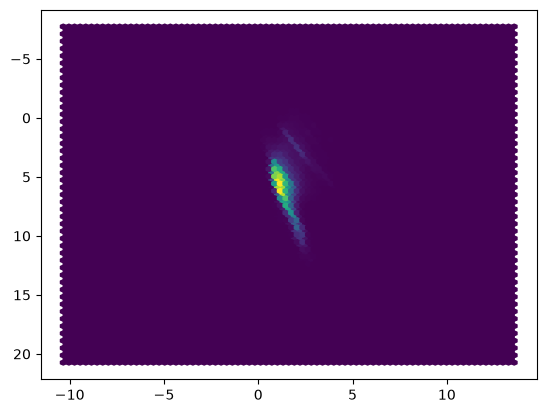

In [ ]:
M_obs = catalog["phot_g_mean_mag"] - 5*np.log10(catalog["barycentric_distance"]) + 5  # ojo unidades pc
plt.hexbin(catalog["color_obs"], M_obs, gridsize=80)
plt.gca().invert_yaxis()

In [ ]:
catalog.select(
    "teff_error",
    "a0_error",
    "ag_error",
    "abp_error",
    "arp_error",
).sum()

teff_error,a0_error,ag_error,abp_error,arp_error
f32,f32,f32,f32,f32
0.0,0.0,0.0,0.0,0.0


## Grilla fija del CMD

No construir esta grilla con cuantiles de la misma muestra evaluada. Aquí se usa un
rango fijo amplio para Gaia. Ajustar resolución según recursos disponibles.

In [ ]:
def compute_oreacle_weights(df: pl.DataFrame, grid: dict) -> np.ndarray:
    # CORRECCIÓN: Eliminamos el * 1e3 porque barycentric_distance ya está en parsecs
    M_G_true, color_true = df.select(
        (pl.col("mag_g") - 5.0 * pl.col("barycentric_distance").log10() + 5.0).alias("M_G_true"),
        (pl.col("mag_bp") - pl.col("mag_rp").alias("color_true")),
    ).to_jax().T

    counts, _, _ = jnp.histogram2d(
        color_true, # El orden en histogram2d es [x, y]
        M_G_true,
        bins=[grid["color_edges"], grid["abs_edges"]],
        density=True
    )
    # Transponemos para que coincida con el ravel() de mu_color/mu_abs_mag
    w_oracle = counts.T.ravel()
    w_oracle = w_oracle / (w_oracle.sum() + 1e-12)
    return w_oracle


def build_fixed_cmd_grid(
    color_range=(-0.5, 9.0),
    abs_mag_range=(-4.0, 16.0),
    n_color=25,
    n_abs_mag=35,
):
    color_edges = np.linspace(color_range[0], color_range[1], n_color + 1)
    mag_edges = np.linspace(abs_mag_range[0], abs_mag_range[1], n_abs_mag + 1)
    color_step = color_edges[1] - color_edges[0]
    mag_step = mag_edges[1] - mag_edges[0]
    color_centers = 0.5 * (color_edges[:-1] + color_edges[1:])
    mag_centers = 0.5 * (mag_edges[:-1] + mag_edges[1:])
    grid_color, grid_mag = np.meshgrid(color_centers, mag_centers, indexing="xy")
    return {
        "mu_color": grid_color.ravel(),
        "mu_abs_mag": grid_mag.ravel(),
        "sigma_color_kernel": np.full(grid_color.size, color_step),
        "sigma_abs_mag_kernel": np.full(grid_color.size, mag_step),
        "color_edges": color_edges,
        "abs_edges": mag_edges,
        "shape": grid_mag.shape,
    }

def prepare_model_data(df: pl.DataFrame, grid: dict, r_min=10.0, r_max=20_000.0) -> dict:
    w_oracle = compute_oreacle_weights(df, grid)
    return {
        "parallax": df["parallax"].to_numpy(),
        "parallax_error": df["parallax_error"].to_numpy(),

        # CORRECCIÓN: Restamos la extinción Ag para obtener la magnitud observada
        "m_obs": df["phot_g_mean_mag"].to_numpy() - df["ag"].to_numpy(),
        # CORRECCIÓN: Ajustamos el color observado para la extinción
        "color_obs": df["color_obs"].to_numpy() - df["abp"].to_numpy() + df["arp"].to_numpy(),

        "sigma_m": df["sigma_g_mag"].to_numpy(),
        "sigma_color": df["sigma_color"].to_numpy(),

        "r_min": float(r_min),
        "r_max": float(r_max),
        "oracle_weights": w_oracle,
        **grid,
    }

## Datos


In [ ]:
N_COLORS = 12
N_ABS_MAG = 15

grid = build_fixed_cmd_grid(
    n_color=N_COLORS,       # Aumentamos resolución al ampliar el rango
    n_abs_mag=N_ABS_MAG,     # Aumentamos resolución al ampliar el rango
    color_range=(-0.5, 9.0),
    abs_mag_range=(-4.0, 16.0),
)

In [ ]:
N_NUTS = 50_000

sub_sample_0 = catalog.sample(n=N_NUTS, seed=SEED + 100).sort("source_id")
sub_model_data_np_0 = prepare_model_data(sub_sample_0, grid, r_min=10.0, r_max=20_000.0)
sub_model_data_0 = {
    key: jnp.asarray(value) if isinstance(value, np.ndarray) else value
    for key, value in sub_model_data_np_0.items()
}

## Modelos

### Modelo 0

In [ ]:
def model_0_parallax_only(parallax, parallax_error, r_min, r_max, **_):
    n_stars = parallax.shape[0]
    with numpyro.plate("star", n_stars):
        distance_pc = numpyro.sample("distance_pc", dist.Uniform(r_min, r_max))
        numpyro.sample("parallax_like", dist.Normal(1000.0 / distance_pc, parallax_error), obs=parallax)

def run_nuts(model, model_data, *, seed, num_samples=2000, num_warmup=1000):
    nuts_kernel = NUTS(model)
    mcmc = MCMC(
        nuts_kernel,
        num_samples=num_samples,
        num_warmup=num_warmup,
        num_chains=2,
        progress_bar=True,
    )
    rng_key = random.PRNGKey(seed)
    mcmc.run(rng_key, **model_data)

    idata = az.from_numpyro(mcmc)
    return mcmc, idata

In [ ]:
mcmc_0, idata_0 = run_nuts(model_0_parallax_only, sub_model_data_0, seed=SEED + 50)

/tmp/ipykernel_46774/3806347616.py:9: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 3000/3000 [01:40<00:00, 29.75it/s, 127 steps of size 3.67e-02. acc. prob=0.86]


### Modelo 1

#### Código Gibbs

In [ ]:
"""Collapsed Gibbs sampler for the fixed-grid CMD model of Leistedt & Hogg.

This is intentionally not a joint HMC/NUTS model.  The sampler targets
``p(b, weights | parallax, magnitude, colour)`` after numerically integrating
each star's distance out of the bin-allocation update.  That is the blocking
scheme in Leistedt & Hogg (2017), section 2.1.

All numerical work is JAX-native, so ``jax.jit`` can place the two Gibbs
updates and the distance draws on an accelerator.  BlackJAX is unnecessary
for these blocks: both conditional distributions have exact draws.
"""

from typing import NamedTuple

import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp


class GibbsState(NamedTuple):
    """State of the collapsed chain."""

    weights: jax.Array
    bins: jax.Array


class CMDData(NamedTuple):
    """Precomputed quantities shared by every Gibbs iteration."""

    log_g: jax.Array
    distance_grid: jax.Array
    log_distance_measure: jax.Array
    log_parallax: jax.Array
    m_obs: jax.Array
    sigma_m: jax.Array
    mu_abs_mag: jax.Array
    sigma_abs_mag_kernel: jax.Array


def _log_magnitude_given_bins(data: CMDData, bins: jax.Array) -> jax.Array:
    """Shared log-magnitude term ``log p(m_s | d, b_s)`` on the distance grid.

    Shape: ``(n_stars, n_distance_grid)``.
    """
    sigma_total = jnp.sqrt(data.sigma_m**2 + data.sigma_abs_mag_kernel[bins] ** 2)
    mean_magnitude = (
        data.mu_abs_mag[bins, None]
        + 5.0 * jnp.log10(data.distance_grid)[None, :]
        - 5.0
    )
    return -0.5 * (
        ((data.m_obs[:, None] - mean_magnitude) / sigma_total[:, None]) ** 2
        + jnp.log(2.0 * jnp.pi * sigma_total[:, None] ** 2)
    )


def _integration_weights(distance_grid: jax.Array) -> jax.Array:
    """Trapezoidal integration weights for a strictly increasing distance grid."""
    deltas = jnp.diff(distance_grid)
    return jnp.concatenate(
        (deltas[:1] / 2.0, (deltas[:-1] + deltas[1:]) / 2.0, deltas[-1:] / 2.0)
    )


def make_cmd_data(
    parallax: jax.Array,
    parallax_error: jax.Array,
    m_obs: jax.Array,
    sigma_m: jax.Array,
    color_obs: jax.Array,
    sigma_color: jax.Array,
    mu_abs_mag: jax.Array,
    mu_color: jax.Array,
    sigma_abs_mag_kernel: jax.Array,
    sigma_color_kernel: jax.Array,
    *,
    distance_min: float,
    distance_max: float,
    n_distance_grid: int = 512,
) -> CMDData:
    """Precompute ``log g[s, b] = log p(data_s | b)`` on a distance grid.

    The integral uses a *uniform prior in linear distance*, matching the
    simplifying prior in Leistedt & Hogg.  Its normalization is independent
    of ``b`` and therefore omitted from ``log_g``.  It must be included only
    when reporting normalized distance posterior densities.

    A common distance grid is required by this collapsed implementation.  Set
    bounds wide enough for every star; truncating a posterior at either bound
    changes the model rather than merely aiding computation.
    """
    if distance_min <= 0.0 or distance_max <= distance_min:
        raise ValueError("Require 0 < distance_min < distance_max.")
    if n_distance_grid < 3:
        raise ValueError("n_distance_grid must be at least 3.")

    parallax = jnp.asarray(parallax)
    parallax_error = jnp.asarray(parallax_error)
    m_obs = jnp.asarray(m_obs)
    sigma_m = jnp.asarray(sigma_m)
    color_obs = jnp.asarray(color_obs)
    sigma_color = jnp.asarray(sigma_color)
    mu_abs_mag = jnp.asarray(mu_abs_mag)
    mu_color = jnp.asarray(mu_color)
    sigma_abs_mag_kernel = jnp.asarray(sigma_abs_mag_kernel)
    sigma_color_kernel = jnp.asarray(sigma_color_kernel)

    # Log spacing resolves both nearby and distant parallax posteriors.  The
    # measure remains dd, hence the separate trapezoidal weights below.
    distance_grid = jnp.exp(
        jnp.linspace(jnp.log(distance_min), jnp.log(distance_max), n_distance_grid)
    )
    log_distance_measure = jnp.log(_integration_weights(distance_grid))

    log_parallax = -0.5 * (
        ((parallax[:, None] - 1000.0 / distance_grid[None, :]) / parallax_error[:, None]) ** 2
        + jnp.log(2.0 * jnp.pi * parallax_error[:, None] ** 2)
    )
    log_color = -0.5 * (
        ((color_obs[:, None] - mu_color[None, :]) /
         jnp.sqrt(sigma_color[:, None] ** 2 + sigma_color_kernel[None, :] ** 2)) ** 2
        + jnp.log(    2.0
            * jnp.pi
            * (sigma_color[:, None] ** 2 + sigma_color_kernel[None, :] ** 2)
        )
    )

    def one_bin(_, bin_index):
        sigma_total = jnp.sqrt(sigma_m**2 + sigma_abs_mag_kernel[bin_index] ** 2)
        mean_magnitude = (
            mu_abs_mag[bin_index] + 5.0 * jnp.log10(distance_grid) - 5.0
        )
        log_magnitude = -0.5 * (
            ((m_obs[:, None] - mean_magnitude[None, :]) / sigma_total[:, None]) ** 2
            + jnp.log(2.0 * jnp.pi * sigma_total[:, None] ** 2)
        )
        log_g_for_bin = logsumexp(
            log_parallax + log_magnitude + log_distance_measure[None, :], axis=-1
        ) + log_color[:, bin_index]
        return None, log_g_for_bin

    _, log_g_by_bin = jax.lax.scan(
        one_bin, None, jnp.arange(mu_abs_mag.shape[0])
    )
    return CMDData(
        log_g=log_g_by_bin.T,
        distance_grid=distance_grid,
        log_distance_measure=log_distance_measure,
        log_parallax=log_parallax,
        m_obs=m_obs,
        sigma_m=sigma_m,
        mu_abs_mag=mu_abs_mag,
        sigma_abs_mag_kernel=sigma_abs_mag_kernel,
    )


def initialize_gibbs(key: jax.Array, data: CMDData) -> GibbsState:
    """Initialize bins from their marginal likelihood under uniform weights."""
    n_bins = data.log_g.shape[1]
    key, bin_key = jax.random.split(key)
    bins = jax.random.categorical(bin_key, data.log_g - jnp.log(n_bins), axis=-1)
    return GibbsState(weights=jnp.full(n_bins, 1.0 / n_bins), bins=bins)


def gibbs_step(key: jax.Array, state: GibbsState, data: CMDData, alpha: jax.Array) -> GibbsState:
    """Perform the two exact collapsed Gibbs updates of Leistedt & Hogg."""
    weights_key, bins_key = jax.random.split(key)
    n_bins = data.log_g.shape[1]
    counts = jnp.bincount(state.bins, length=n_bins)
    weights = jax.random.dirichlet(weights_key, alpha + counts)
    bins = jax.random.categorical(
        bins_key, data.log_g + jnp.log(weights)[None, :], axis=-1
    )
    return GibbsState(weights=weights, bins=bins)


def sample_gibbs_progress(
    key: jax.Array,
    data: CMDData,
    *,
    alpha: float | jax.Array = 1.0,
    num_warmup: int = 1_000,
    num_samples: int = 2_000,
    initial_state: GibbsState | None = None,
    progress: bool = True,
) -> GibbsState:
    """Like ``sample_gibbs`` but with a tqdm progress bar per iteration.

    Replaces ``jax.lax.scan`` with a Python loop of JIT-compiled
    ``gibbs_step`` calls.  Runs the same kernel; the only overhead is the
    host-side loop, which is negligible relative to the per-step JAX work.
    """
    if num_warmup < 0 or num_samples < 1:
        raise ValueError("num_warmup must be non-negative and num_samples positive.")

    n_bins = data.log_g.shape[1]
    alpha = jnp.broadcast_to(jnp.asarray(alpha), (n_bins,))
    key, init_key, step_key = jax.random.split(key, 3)
    state = initialize_gibbs(init_key, data) if initial_state is None else initial_state

    step_fn = jax.jit(gibbs_step)

    iterator = range(num_warmup + num_samples)
    if progress:
        try:
            from tqdm.auto import tqdm

            iterator = tqdm(iterator, desc="gibbs", unit="it")
        except ImportError:
            pass

    weights_acc = []
    bins_acc = []

    for i in iterator:
        step_key, sub_key = jax.random.split(step_key)
        state = step_fn(sub_key, state, data, alpha)

        if i >= num_warmup:
            weights_acc.append(state.weights)
            bins_acc.append(state.bins)

    return GibbsState(
        weights=jnp.stack(weights_acc),
        bins=jnp.stack(bins_acc),
    )


def sample_gibbs(
    key: jax.Array,
    data: CMDData,
    *,
    alpha: float | jax.Array = 1.0,
    num_warmup: int = 1_000,
    num_samples: int = 2_000,
    initial_state: GibbsState | None = None,
) -> GibbsState:
    """Draw collapsed-Gibbs samples; JIT this function at the call site.

    ``alpha`` may be scalar (symmetric Dirichlet) or one value per CMD bin.
    The returned leaves have leading dimension ``num_samples``.
    """
    if num_warmup < 0 or num_samples < 1:
        raise ValueError("num_warmup must be non-negative and num_samples positive.")

    n_bins = data.log_g.shape[1]
    alpha = jnp.broadcast_to(jnp.asarray(alpha), (n_bins,))
    key, init_key, warmup_key, sample_key = jax.random.split(key, 4)
    state = initialize_gibbs(init_key, data) if initial_state is None else initial_state

    warmup_keys = jax.random.split(warmup_key, num_warmup)
    state, _ = jax.lax.scan(
        lambda current, step_key: (gibbs_step(step_key, current, data, alpha), None),
        state,
        warmup_keys,
    )

    def save_step(current: GibbsState, step_key: jax.Array):
        updated = gibbs_step(step_key, current, data, alpha)
        return updated, updated

    sample_keys = jax.random.split(sample_key, num_samples)
    _, samples = jax.lax.scan(save_step, state, sample_keys)
    return samples


def sample_distances(
    key: jax.Array, data: CMDData, bins: jax.Array
) -> jax.Array:
    """Draw ``d_s | b_s, data_s`` for one Gibbs bin-allocation sample.

    The result is a grid-discretized posterior draw of shape ``(n_stars,)``.
    Distances are drawn after the collapsed chain: they do not participate in
    the updates of ``weights`` or ``bins``.
    """
    log_magnitude = _log_magnitude_given_bins(data, bins)
    distance_index = jax.random.categorical(
        key,
        data.log_parallax + log_magnitude + data.log_distance_measure[None, :],
        axis=-1,
    )
    return data.distance_grid[distance_index]


def distance_posterior_mean(data: CMDData, bins: jax.Array) -> jax.Array:
    """Compute ``E[d_s | b_s, data_s]`` on the numerical distance grid."""
    log_magnitude = _log_magnitude_given_bins(data, bins)
    probabilities = jax.nn.softmax(
        data.log_parallax + log_magnitude + data.log_distance_measure[None, :],
        axis=-1,
    )
    return jnp.sum(probabilities * data.distance_grid[None, :], axis=-1)


def sample_distances_all(
    key: jax.Array, data: CMDData, bins_samples: jax.Array
) -> jax.Array:
    """Draw distances for every Gibbs sample in ``bins_samples``.

    Uses ``jax.lax.map`` so each sample is processed sequentially, avoiding
    the ``(num_samples, n_stars, n_distance_grid)`` intermediate that vmap
    would materialise and that exhausts GPU memory for large posteriors.

    Args:
        key: PRNG key.
        data: Precomputed CMD data.
        bins_samples: ``(num_samples, n_stars)`` integer array of bin allocations.

    Returns:
        ``(num_samples, n_stars)`` array of distance draws.
    """
    keys = jax.random.split(key, bins_samples.shape[0])

    def one_sample(args):
        sub_key, bins = args
        return sample_distances(sub_key, data, bins)

    return jax.lax.map(one_sample, (keys, bins_samples))


def distance_posterior_mean_all(
    data: CMDData, bins_samples: jax.Array
) -> jax.Array:
    """Compute posterior-mean distances for every Gibbs sample.

    Sequential (``lax.map``) version of ``distance_posterior_mean`` to avoid
    the OOM that ``jax.vmap`` triggers by materialising a rank-3 intermediate.

    Args:
        data: Precomputed CMD data.
        bins_samples: ``(num_samples, n_stars)`` integer array of bin allocations.

    Returns:
        ``(num_samples, n_stars)`` array of posterior-mean distances.
    """
    def one_sample(bins):
        return distance_posterior_mean(data, bins)

    return jax.lax.map(one_sample, bins_samples)


def to_arviz(
    gibbs: GibbsState,
    data: CMDData,
    *,
    key: jax.Array,
    num_chains: int = 1,
    chain_method: str = "sequential",
) -> "az.InferenceData":
    """Convert Gibbs output to an ArviZ ``InferenceData`` for diagnostics.

    Adds posterior-mean distances as a deterministic variable
    ``distance_pc`` so it is consistent with the NumPyro/PyMC naming used
    elsewhere in the project.

    Requires ``arviz`` and ``numpy``.
    """
    import arviz as az
    import numpy as np

    weights = np.asarray(gibbs.weights)
    bins = np.asarray(gibbs.bins)

    if weights.ndim == 3:
        num_chains, num_samples, n_bins = weights.shape
        n_stars = bins.shape[2]
    else:
        num_samples, n_bins = weights.shape
        n_stars = bins.shape[1]

        if num_chains > 1:
            if num_samples % num_chains != 0:
                raise ValueError(
                    f"num_samples ({num_samples}) must be divisible by num_chains "
                    f"({num_chains})."
                )
            per_chain = num_samples // num_chains
            weights = weights.reshape(num_chains, per_chain, n_bins)
            bins = bins.reshape(num_chains, per_chain, n_stars)
        else:
            weights = weights[None, ...]
            bins = bins[None, ...]

    # Posterior-mean distances: compute sequentially to avoid OOM.
    # Flatten chains for the lax.map pass, then reshape back.
    bins_flat = bins.reshape(-1, n_stars)
    mean_flat = np.asarray(
        jax.jit(sample_distances_all)(key, data, jnp.asarray(bins_flat))
    )
    distance_pc = mean_flat.reshape(num_chains, -1, n_stars)

    return az.from_dict(
        posterior={
            "weights": weights,
            "bins": bins,
            "distance_pc": distance_pc,
        },
        coords={
            "star": np.arange(n_stars),
            "kernel": np.arange(n_bins),
        },
        dims={
            "weights": ["kernel"],
            "bins": ["star"],
            "distance_pc": ["star"],
        },
    )


#### Cálculo

In [ ]:
import inspect

# sub_sample_1 = catalog.sample(n=50_000, seed=SEED + 200).sort("source_id")
sub_sample_1 = sub_sample_0
sub_model_data_np_1 = prepare_model_data(sub_sample_1, grid, r_min=10.0, r_max=20_000.0)

def to_jnp(value):
  return jnp.asarray(value) if isinstance(value, np.ndarray) else value

sub_model_data_1 = {
    name: to_jnp(sub_model_data_np_1[name])
    for name in inspect.signature(make_cmd_data).parameters
    if name in sub_model_data_np_1
}

sub_model_data_1["distance_min"] = 10.0
sub_model_data_1["distance_max"] = 20_000.0
sub_model_data_1["n_distance_grid"] = 512

data = make_cmd_data(**sub_model_data_1)

In [ ]:
# key = jax.random.PRNGKey(0)
# gibbs = sample_gibbs_progress(
#     key, data,
#     alpha=1.0,
#     num_warmup=1_000,
#     num_samples=2_000,
#     progress=True,
# )

chains = [
    sample_gibbs_progress(
        jax.random.PRNGKey(i),
        data,
        alpha=1.0,
        num_warmup=2000,
        num_samples=2000,
    )
    for i in range(2)
]
gibbs = GibbsState(**{
    name: jnp.stack([getattr(chain, name) for chain in chains])
    for name in GibbsState._fields
})

idata_1 = to_arviz(gibbs, data, key=jax.random.PRNGKey(6532), num_chains=2)

gibbs:   0%|          | 0/4000 [00:00<?, ?it/s]

gibbs:   0%|          | 0/4000 [00:00<?, ?it/s]

In [ ]:
M_G_true, color_true = sub_sample_1.select(
    (pl.col("mag_g") - 5.0 * pl.col("barycentric_distance").log10() + 5.0).alias("M_G_true"),
    (pl.col("mag_bp") - pl.col("mag_rp").alias("color_true")),
).to_jax().T

counts, _, _ = jnp.histogram2d(
    color_true, # El orden en histogram2d es [x, y]
    M_G_true,
    bins=[grid["color_edges"], grid["abs_edges"]],
    density=True
)
# Transponemos para que coincida con el ravel() de mu_color/mu_abs_mag
w_oracle = counts.T.ravel()
w_oracle = w_oracle / (w_oracle.sum() + 1e-12)

In [ ]:
w_oracle_jax = jnp.asarray(w_oracle)
log_weights_oracle = jnp.log(w_oracle_jax + 1e-12)

key_init = jax.random.PRNGKey(999)
bins_oracle = jax.random.categorical(
    key_init, data.log_g + log_weights_oracle[None, :], axis=-1
)
state_oracle = GibbsState(weights=w_oracle_jax, bins=bins_oracle)

chains = [
    sample_gibbs_progress(
        jax.random.PRNGKey(42 + i),
        data,
        alpha=1.0,
        num_warmup=1000,
        num_samples=2000,
        initial_state=state_oracle,
    )
    for i in range(2)
]
chain_oracle = GibbsState(**{
    name: jnp.stack([getattr(chain, name) for chain in chains])
    for name in GibbsState._fields
})

idata_oracle = to_arviz(gibbs, data, key=jax.random.PRNGKey(6532), num_chains=2)

gibbs:   0%|          | 0/3000 [00:00<?, ?it/s]

gibbs:   0%|          | 0/3000 [00:00<?, ?it/s]

## Analisis

In [ ]:
# idata_0.to_netcdf(MODELS_DIR / "modelo_0.nc")
# idata_1.to_netcdf(MODELS_DIR / "modelo_1.nc")

In [ ]:
true_dist_0 = sub_sample_0["barycentric_distance"].to_numpy()
metrics_0 = evaluate_distance_posterior(idata_0, true_dist_0, variable="distance_pc")
true_dist_1 = sub_sample_1["barycentric_distance"].to_numpy()
metrics_1 = evaluate_distance_posterior(idata_1, true_dist_1, variable="distance_pc")

pl.DataFrame(map(asdict, (metrics_0, metrics_1)))

variable,n,rmse,mean_bias,mean_relative_bias,coverage_68,coverage_95,mean_width_68,mean_width_95,median_width_95
str,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""distance_pc""",50000,3906.91075,2673.160079,1.085331,0.73146,0.96244,8960.50293,13554.400391,17272.867188
"""distance_pc""",50000,4669.922987,3163.517979,1.351599,0.5087,0.8518,6412.086426,11510.398438,15110.890625


### Visualización de Diagnósticos y Resultados
Generamos gráficos para evaluar la convergencia (diagnósticos) y la calidad de la predicción de distancias.

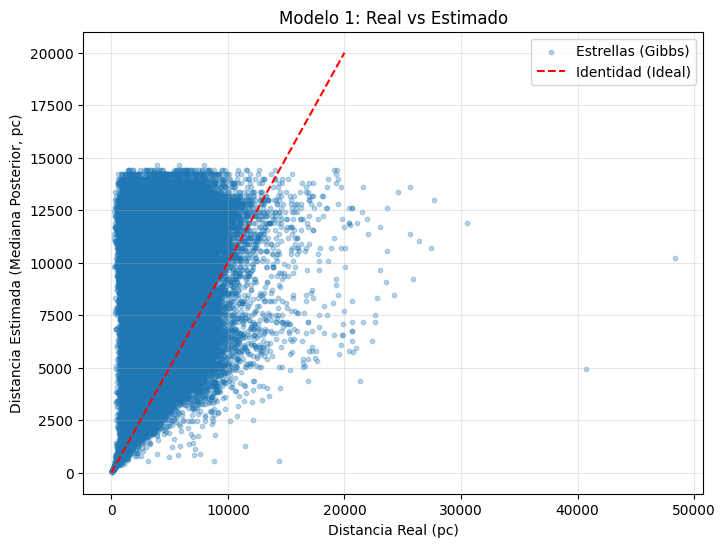

In [ ]:
# 1. Comparación Visual: Distancia Real vs Estimada (Modelo 1)
plt.figure(figsize=(8, 6))
median_dist = idata_1.posterior["distance_pc"].median(dim=["chain", "draw"])

plt.scatter(true_dist_1, median_dist, alpha=0.3, s=10, label="Estrellas (Gibbs)")
plt.plot([0, 20000], [0, 20000], color="red", linestyle="--", label="Identidad (Ideal)")
plt.xlabel("Distancia Real (pc)")
plt.ylabel("Distancia Estimada (Mediana Posterior, pc)")
plt.title("Modelo 1: Real vs Estimado")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Comparación Final de Residuos
Graficamos el error relativo $(d_{est} - d_{true}) / d_{true}$ para ver el comportamiento del sesgo en función de la distancia real.

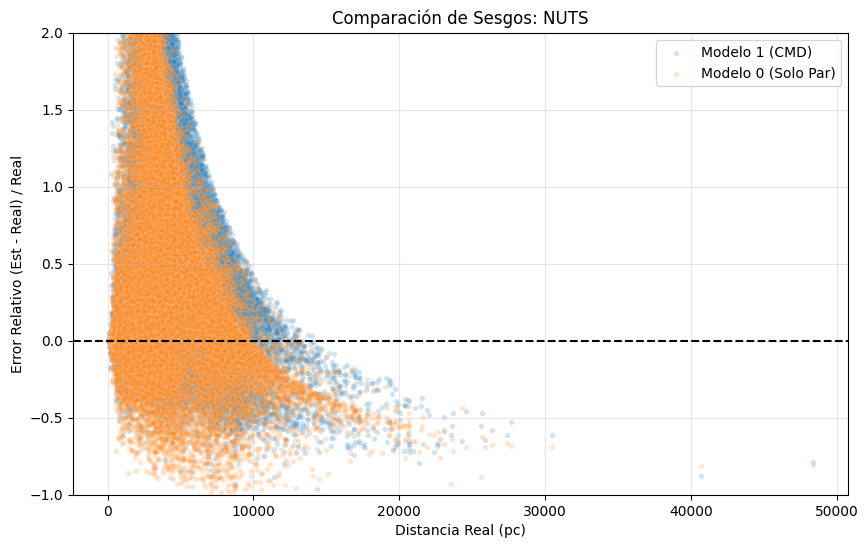

In [ ]:
def get_median_dist(idata):
    return idata.posterior["distance_pc"].median(dim=["chain", "draw"]).values

dists = (
    ("Modelo 1 (CMD)", (get_median_dist(idata_1), true_dist_1)),
    ("Modelo 0 (Solo Par)", (get_median_dist(idata_0), true_dist_0)),
)

plt.figure(figsize=(10, 6))
for name, (d_median, true_dist) in dists:
    residual_rel = (d_median - true_dist) / true_dist
    sns.scatterplot(x=true_dist, y=residual_rel, alpha=0.2, s=15, label=name)

plt.axhline(0, color="black", linestyle="--")
plt.ylim(-1, 2)
plt.xlabel("Distancia Real (pc)")
plt.ylabel("Error Relativo (Est - Real) / Real")
plt.title("Comparación de Sesgos: NUTS")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

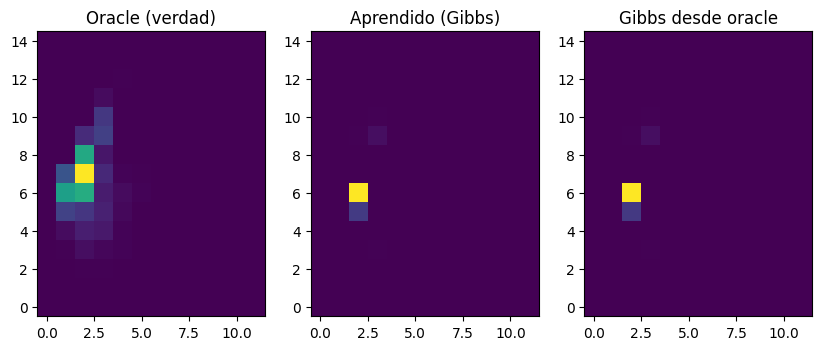

In [ ]:
n_color = N_COLORS
n_abs_mag = N_ABS_MAG
n_bins = n_color * n_abs_mag

f_oracle_chain = jnp.asarray(chain_oracle.weights).reshape(-1, n_bins).mean(axis=0)
f_learned = np.asarray(gibbs.weights).reshape(-1, n_bins).mean(axis=0)
f_oracle = np.asarray(w_oracle)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(f_oracle.reshape(n_abs_mag, n_color), origin="lower")
axes[0].set_title("Oracle (verdad)")
axes[1].imshow(f_learned.reshape(n_abs_mag, n_color), origin="lower")
axes[1].set_title("Aprendido (Gibbs)")
axes[2].imshow(np.asarray(f_oracle_chain).reshape(n_abs_mag, n_color), origin="lower")
axes[2].set_title("Gibbs desde oracle")
plt.show()